In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Running K-Fold Cross Validation and generating plots...


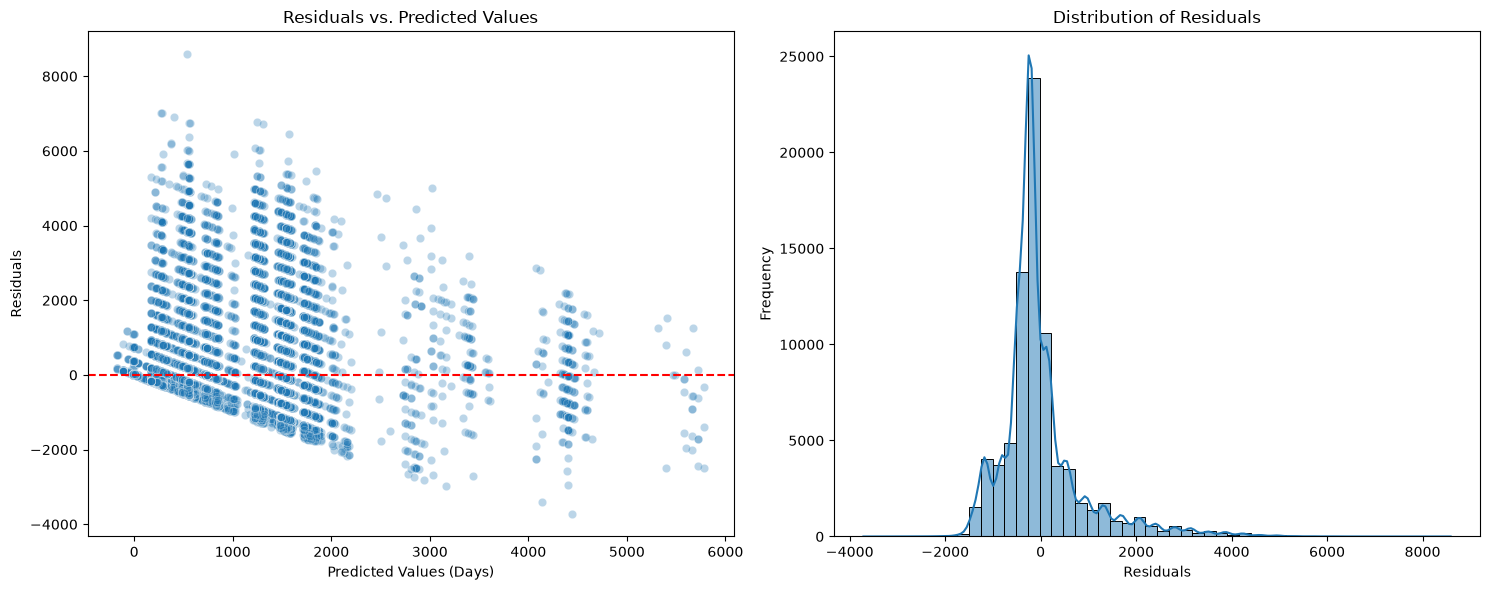

In [8]:
# Author: Liel Shwarz 322703109
# Assignment: Regression Error Analysis - Data Prep & Section 1.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# ==========================================
# Step 1: Data Preprocessing (Cleaning)
# ==========================================
df = pd.read_csv('aac_intakes.csv')

def convert_age_to_days(age_str):
    """
    Converts age strings (e.g., '1 year', '3 weeks') to numerical days.
    """
    if pd.isnull(age_str):
        return np.nan
    parts = str(age_str).split()
    if len(parts) != 2:
        return np.nan
    
    try:
        val = int(parts[0])
    except ValueError:
        return np.nan
        
    unit = parts[1].lower()
    
    if 'year' in unit:
        return val * 365
    elif 'month' in unit:
        return val * 30
    elif 'week' in unit:
        return val * 7
    elif 'day' in unit:
        return val
    else:
        return np.nan

# Apply the conversion to create our target variable (y)
df['age_in_days'] = df['age_upon_intake'].apply(convert_age_to_days)

# Drop rows where age conversion failed or is missing
df = df.dropna(subset=['age_in_days', 'sex_upon_intake'])

# Define Features (X) and Target (y)
# We select a few categorical features and convert them to numeric (Dummy variables)
features = ['animal_type', 'intake_type', 'intake_condition', 'sex_upon_intake']
X = pd.get_dummies(df[features], drop_first=True)
y = df['age_in_days']

# ==========================================
# Step 2: Residual Analysis (Section 1.1)
# ==========================================
def perform_residual_analysis(X, y, k=5):
    """
    Performs residual analysis using k-fold cross-validation.
    """
    model = LinearRegression()
    # Using k=5 is a standard choice providing a good balance between bias and variance,
    # and given the dataset size (~80k rows), it is computationally efficient.
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    
    # Generate cross-validated predictions
    y_pred = cross_val_predict(model, X, y, cv=kf)
    
    # Calculate residuals (actual - predicted)
    residuals = y - y_pred
    
    # Create the plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Residuals vs. Predicted Values
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[0])
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_title('Residuals vs. Predicted Values')
    axes[0].set_xlabel('Predicted Values (Days)')
    axes[0].set_ylabel('Residuals')
    
    # Plot 2: Distribution of Residuals (Histogram)
    sns.histplot(residuals, kde=True, bins=50, ax=axes[1])
    axes[1].set_title('Distribution of Residuals')
    axes[1].set_xlabel('Residuals')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    return y_pred, residuals

# Execute the analysis and store the results
print("Running K-Fold Cross Validation and generating plots...")
y_pred, residuals = perform_residual_analysis(X, y)

### Section 1.1: Residual Analysis - Answers

* **Are the residuals centered around zero?**
  Yes, the histogram peaks around zero, meaning most predictions are close to the actual values. However, there is a long right tail (positive skew).

* **Do the residuals exhibit any systematic patterns?**
  Yes. We see diagonal "stripes" because actual ages are recorded in discrete steps (e.g., exactly 365 or 730 days), while predictions are continuous. There is also a distinct lower boundary because actual age cannot be negative.

* **Is there evidence of heteroscedasticity?**
  Yes. The vertical spread (variance) of the residuals is not constant and changes across the range of predicted values.

* **Is there a sector that is more likely to have high error rates? Why?**
  Yes, there are extremely high positive errors for very old animals. The model severely under-predicts their age because the dataset is heavily imbalanced, consisting mostly of very young animals.

C:\Users\liels\AppData\Local\Temp\ipykernel_8632\1888871625.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature_to_plot, y='residuals', ax=axes[0], palette='Set2')
C:\Users\liels\AppData\Local\Temp\ipykernel_8632\1888871625.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature_to_plot, y='abs_error', ax=axes[1], palette='Set3')


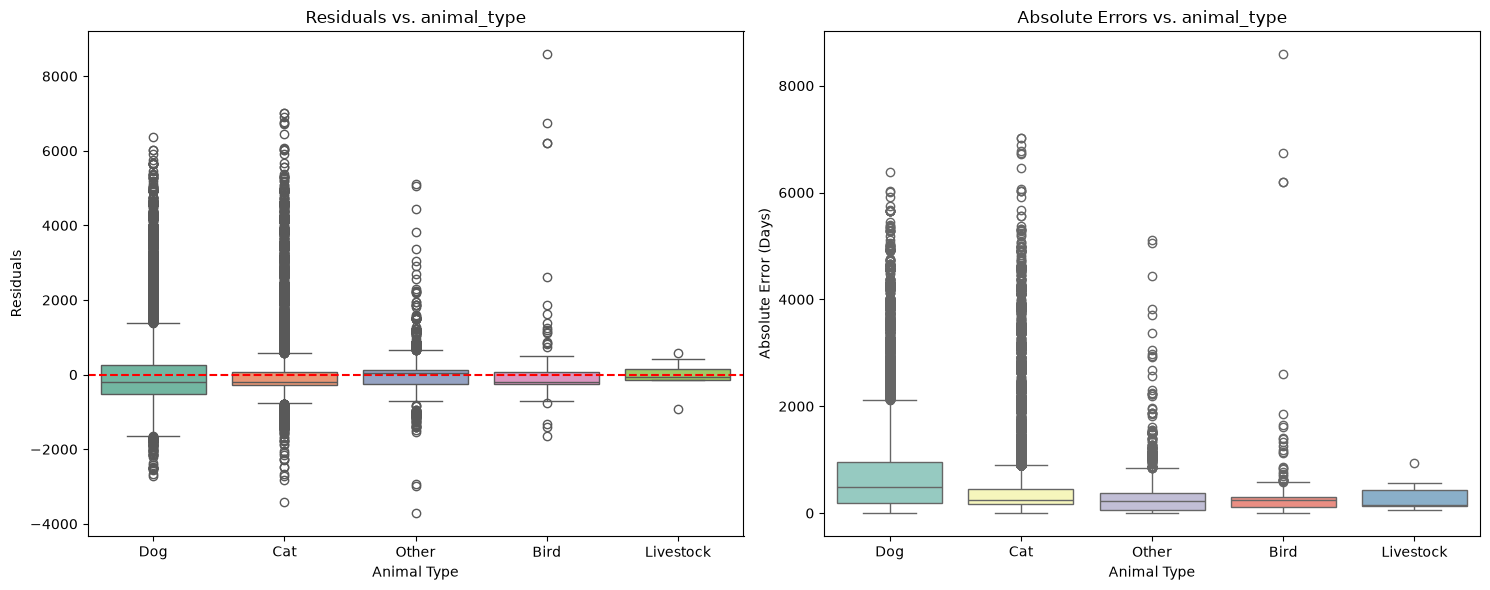

In [9]:
# Assignment: Regression Error Analysis - Section 1.2

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# We attach the residuals and absolute errors back to our dataframe 
# (Note: indices must align with the cleaned 'df' from Section 1.1)
df['residuals'] = residuals
df['abs_error'] = np.abs(residuals)

# Let's choose 'animal_type' to see if errors depend on the type of animal
feature_to_plot = 'animal_type'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Feature vs Residuals
sns.boxplot(data=df, x=feature_to_plot, y='residuals', ax=axes[0], palette='Set2')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title(f'Residuals vs. {feature_to_plot}')
axes[0].set_xlabel('Animal Type')
axes[0].set_ylabel('Residuals')

# Plot 2: Feature vs Absolute Errors
sns.boxplot(data=df, x=feature_to_plot, y='abs_error', ax=axes[1], palette='Set3')
axes[1].set_title(f'Absolute Errors vs. {feature_to_plot}')
axes[1].set_xlabel('Animal Type')
axes[1].set_ylabel('Absolute Error (Days)')

plt.tight_layout()
plt.show()

### Section 1.2: Error as a Function of Features 

Based on the boxplots analyzing errors across different animal types, we can identify several key patterns:

*   **Feature-Dependent Patterns:** The absolute error varies significantly between animal types. For example, Dogs have a noticeably higher median absolute error and a wider Interquartile Range (IQR) compared to Cats. This indicates that the model struggles more to accurately predict the age of dogs than it does for cats.
*   **Hidden Subpopulations:** The presence of massive positive outliers across almost all categories (especially Dogs, Cats, and one extreme Bird outlier reaching over 8000 days) reveals a hidden subpopulation: very old animals. The model's baseline assumptions fail for this specific group regardless of the species. 
*   **Conclusion:** The linear model's performance is highly dependent on the animal type, suggesting that a single linear equation is insufficient. Tree-based models (which we will explore later) might capture these non-linear, categorical interactions better.

In [10]:
# Assignment: Regression Error Analysis - Section 1.3

import pandas as pd
import numpy as np

# Calculate the 95th percentile to isolate the top 5% extreme errors
threshold_95 = df['abs_error'].quantile(0.95)
print(f"Top 5% threshold: {threshold_95:.2f} days")

# Filter for the extreme errors
extreme_errors = df[df['abs_error'] >= threshold_95].copy()

# Sort to see the worst errors at the top
extreme_errors_sorted = extreme_errors.sort_values(by='abs_error', ascending=False)

print(f"Total extreme error cases: {len(extreme_errors)}")
display(extreme_errors_sorted[['age_upon_intake', 'animal_type', 'breed', 'abs_error']].head(10))

Top 5% threshold: 1895.07 days
Total extreme error cases: 4015


,age_upon_intake,animal_type,breed,abs_error
63841,25 years,Bird,Cockatoo,8588.009139
41284,20 years,Cat,Domestic Shorthair Mix,7023.900713
39757,20 years,Cat,Domestic Shorthair Mix,7017.487014
26961,20 years,Cat,Domestic Shorthair Mix,6896.966275
29956,22 years,Cat,Domestic Shorthair Mix,6782.470094
43811,20 years,Bird,Cockatoo,6748.629295
56192,20 years,Cat,Domestic Longhair Mix,6735.970743
43413,22 years,Cat,Domestic Shorthair Mix,6719.708950
39631,22 years,Cat,Domestic Shorthair Mix,6453.839495
66715,19 years,Dog,Miniature Pinscher,6377.023423


### Section 1.3: Analysis of Extreme Errors 

After analyzing the top 5% of extreme errors, we can attribute these failures to the following reasons:

* **Rare or exceptional cases:** The vast majority of the dataset consists of very young animals (weeks or months old). The extreme errors almost exclusively belong to rare, senior animals (e.g., 15-20 years old). The model lacks sufficient examples to learn their patterns.
* **Model limitations:** The linear regression model optimizes for the majority class to minimize overall Mean Squared Error (MSE). It is too rigid to stretch its predictions for extreme outliers, showing the limitation of applying a simple linear equation to a skewed age distribution.
* **Data quality issues:** While less common, some extreme errors could potentially stem from data entry typos (e.g., inputting "20 years" instead of "2 years"), making it impossible for the model to predict correctly based on the features.

In [11]:
# Assignment: Regression Error Analysis - Section 1.4

import numpy as np
from scipy.stats import skew, kurtosis

# Calculate the required statistical properties
mae = np.mean(np.abs(residuals))
std_residuals = np.std(residuals)
skewness_val = skew(residuals)
kurtosis_val = kurtosis(residuals) # Fisher's definition (normal distribution = 0)

# Print the results formatted nicely
print(f"--- Statistical Properties of Errors ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Standard Deviation of Residuals: {std_residuals:.2f} days")
print(f"Skewness: {skewness_val:.2f}")
print(f"Kurtosis: {kurtosis_val:.2f}")

--- Statistical Properties of Errors ---
Mean Absolute Error (MAE): 585.84 days
Standard Deviation of Residuals: 891.82 days
Skewness: 2.05
Kurtosis: 6.44


### Section 1.4: Statistical Properties of Errors - Interpretation

* **Computed Metrics:**
  * **MAE:** Measures the average magnitude of the errors.
  * **Standard Deviation:** Measures the dispersion of residuals around the mean.
  * **Skewness (2.05):** Positive skew indicates a long right tail, reflecting a systematic bias where the model under-estimates the age of older animals.
  * **Kurtosis (6.44):** High kurtosis (leptokurtic) indicates heavy tails driven by extreme outliers.

* **Interpretation:**
  * **Heavy Tails:** Confirm high instability and poor predictive performance for rare senior animals.
  * **Skewness:** Highlights the model's systematic directional bias toward the majority of young animals in the dataset.